In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")

df

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47923,36484665,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9,4.262680
47924,36485057,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36,3.713572
47925,36485431,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27,4.753590
47926,36485609,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2,4.025352


In [7]:
features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews"
]

target = "log_price"

In [8]:
from sklearn.model_selection import train_test_split

features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews"
]

target = "log_price"
df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(38342, 11) (9586, 11)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Elastic Net": ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,Model,RMSE,MAE,R2
1,Random Forest,0.381963,0.285870,0.646954
2,Gradient Boosting,0.395288,0.300264,0.621893
0,Elastic Net,0.432001,0.329969,0.548396


In [25]:
from sklearn.model_selection import cross_validate

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "CV_RMSE_mean": -scores["test_rmse"].mean(),
        "CV_RMSE_std": scores["test_rmse"].std(),
        "CV_MAE_mean": -scores["test_mae"].mean(),
        "CV_R2_mean": scores["test_r2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_RMSE_mean")
cv_results_df

,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean
1,Random Forest,0.389307,0.006789,0.290205,0.639635
2,Gradient Boosting,0.398816,0.006550,0.301006,0.621819
0,Elastic Net,0.435658,0.004621,0.330909,0.548697


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline

elastic_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=50000, random_state=42))
])

elastic_param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    elastic_pipe,
    param_grid=elastic_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

elastic_search.fit(X_train, y_train)

print("Best Elastic Net parameters:")
print(elastic_search.best_params_)

print("Best Elastic Net CV RMSE:")
print(-elastic_search.best_score_)

Best Elastic Net parameters:
{'model__alpha': 0.0001, 'model__l1_ratio': 0.1}
Best Elastic Net CV RMSE:
0.4126270088652456


In [27]:
best_elastic = elastic_search.best_estimator_

y_pred_elastic = best_elastic.predict(X_test)

elastic_tuned_results = {
    "Model": "Tuned Elastic Net",
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_elastic)),
    "MAE": mean_absolute_error(y_test, y_pred_elastic),
    "R2": r2_score(y_test, y_pred_elastic)
}

elastic_tuned_results

{'Model': 'Tuned Elastic Net',
 'RMSE': np.float64(0.410030833215985),
 'MAE': 0.31258349864943674,
 'R2': 0.5931627292066357}

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_leaf": [1, 2, 5]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)

Best parameters: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_depth': 15}
Best CV RMSE: 0.38935659787294274


In [29]:
best_rf = rf_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

rf_tuned_results = {
    "Model": "Tuned Random Forest",
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "R2": r2_score(y_test, y_pred_rf)
}

rf_tuned_results

{'Model': 'Tuned Random Forest',
 'RMSE': np.float64(0.38106009295148946),
 'MAE': 0.2855996860742817,
 'R2': 0.6486219414522082}

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 2, 5]
}

gb_search = GridSearchCV(
    gb_pipe,
    param_grid=gb_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_search.best_params_)

print("Best Gradient Boosting CV RMSE:")
print(-gb_search.best_score_)

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}
Best Gradient Boosting CV RMSE:
0.3912740134543012


In [31]:
best_gb = gb_search.best_estimator_

y_pred_gb = best_gb.predict(X_test)

gb_tuned_results = {
    "Model": "Tuned Gradient Boosting",
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    "MAE": mean_absolute_error(y_test, y_pred_gb),
    "R2": r2_score(y_test, y_pred_gb)
}

gb_tuned_results

{'Model': 'Tuned Gradient Boosting',
 'RMSE': np.float64(0.38608173991588274),
 'MAE': 0.2923241969667152,
 'R2': 0.6392999318922634}

In [32]:
tuned_results_df = pd.DataFrame([
    elastic_tuned_results,
    gb_tuned_results,
    rf_tuned_results
])

tuned_results_df[["RMSE", "MAE", "R2"]] = tuned_results_df[["RMSE", "MAE", "R2"]].round(4)

tuned_results_df = tuned_results_df.sort_values("RMSE")

tuned_results_df

,Model,RMSE,MAE,R2
2,Tuned Random Forest,0.3811,0.2856,0.6486
1,Tuned Gradient Boosting,0.3861,0.2923,0.6393
0,Tuned Elastic Net,0.4100,0.3126,0.5932


In [33]:
baseline_results_clean = results_df.copy()
baseline_results_clean["Model Type"] = "Baseline"

tuned_results_clean = tuned_results_df.copy()
tuned_results_clean["Model Type"] = "Tuned"

model_comparison_all = pd.concat(
    [baseline_results_clean, tuned_results_clean],
    ignore_index=True
)

model_comparison_all[["RMSE", "MAE", "R2"]] = model_comparison_all[["RMSE", "MAE", "R2"]].round(4)

model_comparison_all.sort_values(["Model", "Model Type"])

,Model,RMSE,MAE,R2,Model Type
2,Elastic Net,0.4320,0.3300,0.5484,Baseline
1,Gradient Boosting,0.3953,0.3003,0.6219,Baseline
0,Random Forest,0.3820,0.2859,0.6470,Baseline
5,Tuned Elastic Net,0.4100,0.3126,0.5932,Tuned
4,Tuned Gradient Boosting,0.3861,0.2923,0.6393,Tuned
3,Tuned Random Forest,0.3811,0.2856,0.6486,Tuned


In [41]:
print("Best Elastic Net parameters:")
print(elastic_search.best_params_)

print("Best Gradient Boosting parameters:")
print(gb_search.best_params_)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

Best Elastic Net parameters:
{'model__alpha': 0.0001, 'model__l1_ratio': 0.1}
Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}
Best Random Forest parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_depth': 15}


In [45]:
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
X = df[features].copy()
y = df["log_price"].copy()

In [34]:
best_rf_model = best_rf.named_steps["model"]

feature_names_num = numeric_features

feature_names_cat = best_rf.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

feature_names = list(feature_names_num) + list(feature_names_cat)

importances = best_rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
232,room_type_Entire home/apt,0.504084
1,longitude,0.130505
0,latitude,0.104653
6,availability_365,0.059231
2,minimum_nights,0.037384
4,reviews_per_month,0.033232
10,neighbourhood_group_Manhattan,0.032668
3,number_of_reviews,0.029081
5,calculated_host_listings_count,0.025756
139,neighbourhood_Midtown,0.008175


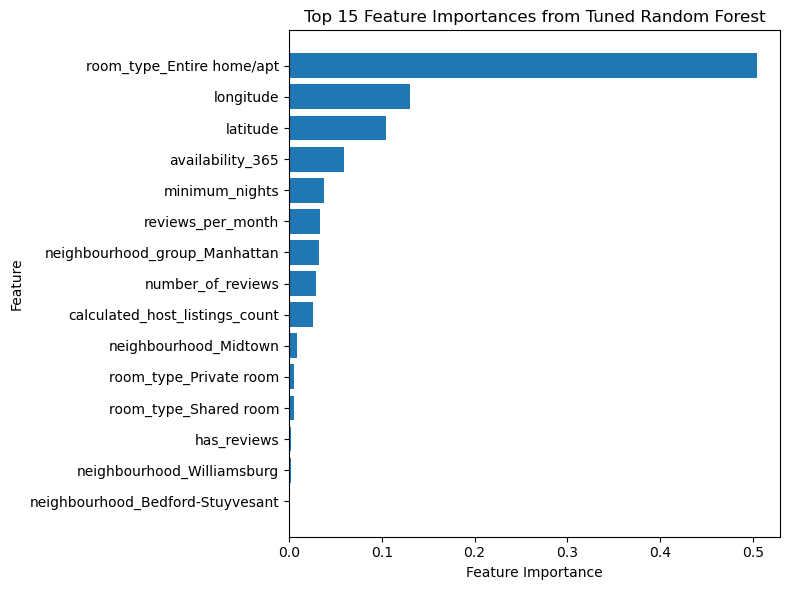

In [35]:
top_features = feature_importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances from Tuned Random Forest")
plt.tight_layout()
plt.show()